In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import colorcet as cc
from rich import print
import colorcet as cc
import matplotlib.pyplot as plt

from params import setup

In [3]:
sc.settings._vector_friendly = True

# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"

In [4]:
FIGURE_DIR = "/home/nathanl/scviva_paper/crc_visium_hd/figures/figures_journal/"

# Building the replaced adata object

In [ ]:
target_cell_type = "Macrophages"
target_region = "Tumor"  # Changed from list to string
source_regions = ["Stroma (Myofibroblast/SM/Endothelial)"]  # Changed to list for consistency

DATA_FOLDER: str = "/home/nathanl/Data/VisiumHD_CRC/"
DATA_FILE: str = "adata_legacy_hvg4k.h5ad"
adata_path: str = DATA_FOLDER + DATA_FILE
adata = sc.read_h5ad(adata_path)

FIGURES_FOLDER: str = "/home/nathanl/scviva_paper/crc_visium_hd/figures/"

# for the data
LABEL: str = "cell_type_coarse"
COORDS: str = "spatial"
BATCH: str = "sample"
SAMPLE: str = "sample"
CELL_TYPE: str = "cell_type_coarse"
NICHE: str = "region_label"

# Count how many endothelial cells are in target region
n_replace = adata[adata.obs[LABEL] == target_cell_type].obs[NICHE].value_counts()[target_region]
n_replace

np.int64(1603)

In [63]:
adata.obs[LABEL].value_counts()

cell_type_coarse
Tumor                                 95727
Plasma B cells                        27174
Stromal (Fibroblast-like)             23634
Myofibroblasts                        22397
Goblet cells                          15340
Smooth muscle                         12045
Endothelial cells                      8040
Neutrophils / Inflammatory myeloid     6198
Macrophages                            4266
Plasma B cells / Fibroblast mix        2916
Lymphoid (T cells / ILC-like)          1328
Interferon-response epithelial          933
Glial-like / Stromal                    291
Name: count, dtype: int64

In [64]:
adata.obs[NICHE].value_counts()

region_label
Tumor                                     74155
Tumor periphery (EMT/Fibro/Neutro mix)    59588
Immune-rich (B cell/Goblet/SM+)           59067
Stroma (Myofibroblast/SM/Endothelial)     27479
Name: count, dtype: int64

In [65]:
print(adata)
# Filter out cells with very low counts to prevent NaN during training
counts = adata.layers["counts"]
if hasattr(counts, "toarray"):
    cell_counts = counts.toarray().sum(axis=1)
else:
    cell_counts = counts.sum(axis=1)

n_cells_before = adata.n_obs
min_counts = 10  # Minimum counts per cell
adata = adata[cell_counts >= min_counts].copy()
print(f"Filtered {n_cells_before - adata.n_obs} cells with < {min_counts} counts")
print(adata)

AnnData object with n_obs × n_vars = 220289 × 4000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 
'region_label'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 
'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.6', 
'distance_neighbor', 'index_neighbor', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 
'qz1_m_niche_ct', 'simvi25_all_mae_50', 'simvi25_both_mae_50', 'simvi25_interact_mae_50', 
'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

Filtered 2700 cells with < 10 counts

AnnData object with n_obs × n_vars = 217589 × 4000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 
'region_label'
    var: 'gene_ids', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 
'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.6', 
'distance_neighbor', 'index_neighbor', 'neighborhood_composition', 'niche_distances', 'niche_indexes', 
'qz1_m_niche_ct', 'simvi25_all_mae_50', 'simvi25_both_mae_50', 'simvi25_interact_mae_50', 
'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

In [66]:
adata_seed = adata.copy()

# keys_to_remove = [
#     "simvi_both",
#     "simvi_both_06",
#     "simvi_both_07",
#     "simvi_both_08",
#     "simvi_both_MDE",
#     "simvi_both_MDE_06",
#     "simvi_both_MDE_07",
#     "simvi_both_MDE_08",
#     "simvi_interact",
#     "simvi_interact_06",
#     "simvi_interact_07",
#     "simvi_interact_08",
#     "simvi_interact_MDE",
#     "simvi_interact_MDE_06",
#     "simvi_interact_MDE_07",
#     "simvi_interact_MDE_08",
#     "simvi_intrinsic",
#     "simvi_intrinsic_06",
#     "simvi_intrinsic_07",
#     "simvi_intrinsic_08",
#     "simvi_intrinsic_MDE",
#     "simvi_intrinsic_MDE_06",
#     "simvi_intrinsic_MDE_07",
#     "simvi_intrinsic_MDE_08",
#     # "X_banksy_02_harmony",
#     "X_banksy_02_harmony_GABAergic",
#     "X_banksy_02_harmony_astrocyte",
#     "X_banksy_02_harmony_endothelial",
#     "X_banksy_02_harmony_glutamatergic",
#     "X_banksy_02_harmony_microglial",
#     "X_banksy_02_harmony_oligodendrocyte",
#     "X_banksy_02_harmony_oligodendrocyte_precursor",
#     "X_banksy_02_harmony_pericyte",
#     "X_nicheformer",
#     "X_nicheformer_e5",
#     # "X_pca",
#     # "X_resolvi",
#     "X_resolvi_MDE",
#     # "X_spatial",
#     "X_umap",
#     "banksy_pc_20_lambda_0.0",
#     "banksy_pc_20_lambda_0.0_GABAergic",
#     "banksy_pc_20_lambda_0.0_astrocyte",
#     "banksy_pc_20_lambda_0.0_endothelial",
#     "banksy_pc_20_lambda_0.0_glutamatergic",
#     "banksy_pc_20_lambda_0.0_microglial",
#     "banksy_pc_20_lambda_0.0_oligodendrocyte",
#     "banksy_pc_20_lambda_0.0_oligodendrocyte_precursor",
#     "banksy_pc_20_lambda_0.0_pericyte",
#     # "banksy_pc_20_lambda_0.2",
#     "banksy_pc_20_lambda_0.2_GABAergic",
#     "banksy_pc_20_lambda_0.2_astrocyte",
#     "banksy_pc_20_lambda_0.2_endothelial",
#     "banksy_pc_20_lambda_0.2_glutamatergic",
#     "banksy_pc_20_lambda_0.2_microglial",
#     "banksy_pc_20_lambda_0.2_oligodendrocyte",
#     "banksy_pc_20_lambda_0.2_oligodendrocyte_precursor",
#     "banksy_pc_20_lambda_0.2_pericyte",
#     "banksy_pc_20_lambda_0.4",
#     "banksy_pc_20_lambda_0.4_astrocyte",
#     # "banksy_pc_20_lambda_0.5",
#     # "banksy_pc_20_lambda_0.6",
#     # "distance_neighbor",
#     # "index_neighbor",
#     "simvi25_all_mae_50",
#     "simvi25_all_mae_80",
#     "simvi25_both_mae_50",
#     "simvi25_both_mae_80",
#     "simvi25_interact_mae_50",
#     "simvi25_interact_mae_80",
#     "simvi25_intrinsic_mae_50",
#     "simvi25_intrinsic_mae_80",
#     # "spatial",
# ]

# for key in keys_to_remove:
#     if key in adata.obsm:
#         del adata.obsm[key]


# print(adata)

adata_seed.write_h5ad(f"/home/nathanl/Data/VisiumHD_CRC/adata_{target_cell_type}_replaced.h5ad")

In [ ]:
import numpy as np
import anndata as ad
import scanpy as sc
import pandas as pd

n_sampled_per_batch = 1500  # you can reduce or raise this as needed

# Load data
adata = sc.read_h5ad(f"/home/nathanl/Data/VisiumHD_CRC/adata_{target_cell_type}_replaced.h5ad")
adata.obs["replacement_status"] = "untouched"  # default

# Collectors
all_astro_sampled = []
all_source_original = []
all_replaced_ids = []

# Iterate over each brain section (slide)
for batch in adata.obs[BATCH].unique():
    print(f"\nProcessing batch: {batch}")
    batch_mask = adata.obs[BATCH] == batch

    # --- Select astrocytes in Isocortex (target) and source regions (Thalamus, Hypothalamus)
    target_astro_mask = (adata.obs[LABEL] == target_cell_type) & (adata.obs[NICHE] == target_region) & batch_mask
    source_astro_mask = (adata.obs[LABEL] == target_cell_type) & (adata.obs[NICHE].isin(source_regions)) & batch_mask

    target_astro = adata[target_astro_mask].copy()
    source_astro = adata[source_astro_mask].copy()

    n_target = target_astro.shape[0]
    n_source = source_astro.shape[0]
    print(f"  n_target={n_target}, n_source={n_source}")

    if n_target < 1 or n_source < 1:
        print("  Skipping batch (not enough target/source astrocytes)")
        continue

    n_sampled = min(n_sampled_per_batch, n_target, n_source)
    print(f"  Sampling {n_sampled} cells for replacement")

    # --- Sample target and source cells randomly
    target_ids = np.random.choice(target_astro.obs_names, n_sampled, replace=False)
    target_subset = target_astro[target_ids].copy()

    sampled_ids = np.random.choice(source_astro.obs_names, n_sampled, replace=False)
    astro_sampled = source_astro[sampled_ids].copy()
    source_original = astro_sampled.copy()

    astro_sampled.obsm[COORDS] = target_subset.obsm[COORDS].copy()

    # --- Metadata updates
    astro_sampled.obs[NICHE] = target_region
    astro_sampled.obs[BATCH] = batch
    astro_sampled.obs[SAMPLE] = batch
    astro_sampled.obs_names = [f"{idx}_replaced" for idx in sampled_ids]
    astro_sampled.obs["replacement_status"] = "duplicated"

    source_original.obs["replacement_status"] = "original"

    # --- Untouched target astrocytes (not replaced)
    target_unused_ids = list(set(target_astro.obs_names) - set(target_ids))
    adata.obs.loc[target_unused_ids, "replacement_status"] = "untouched"

    # --- Track replaced cells for removal
    all_replaced_ids.extend(target_ids)
    all_astro_sampled.append(astro_sampled)
    all_source_original.append(source_original)

# --- Remove replaced target astrocytes
adata = adata[~adata.obs_names.isin(all_replaced_ids)].copy()

# --- Remove source astrocytes that were sampled (originals)
from functools import reduce

sampled_source_ids = reduce(
    lambda x, y: x.union(y), [a.obs_names.str.replace("_replaced", "", regex=False) for a in all_astro_sampled]
)
adata = adata[~adata.obs_names.isin(sampled_source_ids)].copy()

# --- Final combined AnnData
adata_displaced = ad.concat([adata] + all_source_original + all_astro_sampled, axis=0)
print(f"\nFinal shape after per-batch displacement: {adata_displaced.shape}")

Processing batch: Visium HD CRC

n_target=1546, n_source=398

Sampling 398 cells for replacement

Final shape after per-batch displacement: (217589, 4000)

/tmp/ipykernel_1021402/4192424589.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


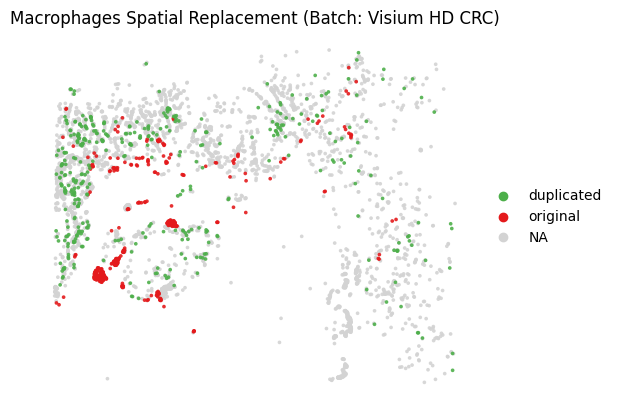

In [25]:
# Pick one batch to plot
batch_to_plot = adata_displaced.obs[BATCH].unique()[0]
plot_mask = (
    (adata_displaced.obs[BATCH] == batch_to_plot)
    & (adata_displaced.obs[LABEL] == target_cell_type)
    & (adata_displaced.obs["replacement_status"].isin(["original", "duplicated", "untouched"]))
)

sc.pl.spatial(
    adata_displaced[plot_mask],
    color="replacement_status",
    size=1.5,
    alpha=0.9,
    spot_size=150,
    groups=[
        "duplicated",
        "original",
    ],
    title=f"{target_cell_type} Spatial Replacement (Batch: {batch_to_plot})",
    palette=["#4daf4a", "#e41a1c", "#984ea3"],  # red, green, purple
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURE_DIR}crc_{target_cell_type}_replacement_{batch_to_plot}.svg", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURE_DIR}crc_{target_cell_type}_replacement_{batch_to_plot}.png", bbox_inches="tight", dpi=300)

In [71]:
adata_displaced.obs_names

Index(['cellid_000000003-1', 'cellid_000000004-1', 'cellid_000000005-1',
       'cellid_000000006-1', 'cellid_000000007-1', 'cellid_000000008-1',
       'cellid_000000009-1', 'cellid_000000010-1', 'cellid_000000011-1',
       'cellid_000000012-1',
       ...
       'cellid_000162254-1_replaced', 'cellid_000161393-1_replaced',
       'cellid_000164543-1_replaced', 'cellid_000119849-1_replaced',
       'cellid_000118759-1_replaced', 'cellid_000083971-1_replaced',
       'cellid_000165382-1_replaced', 'cellid_000115258-1_replaced',
       'cellid_000162736-1_replaced', 'cellid_000049318-1_replaced'],
      dtype='object', length=217589)

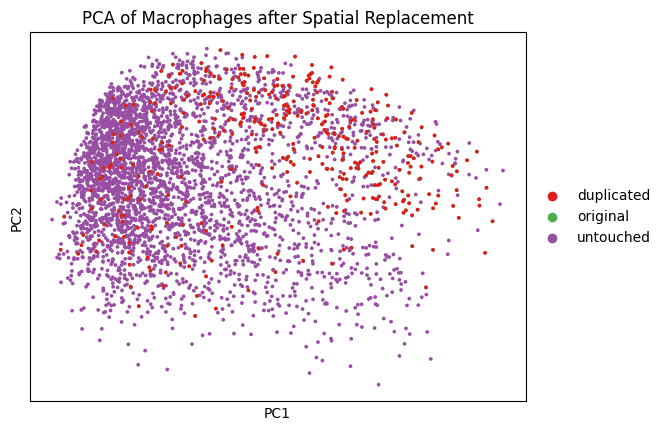

In [72]:
# run PCA then generate UMAP plots
adata_displaced_target_type = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
sc.tl.pca(adata_displaced_target_type, svd_solver="arpack")
sc.pl.pca(
    adata_displaced_target_type,
    color="replacement_status",
    title=f"PCA of {target_cell_type} after Spatial Replacement",
    palette=["#e41a1c", "#4daf4a", "#984ea3"],
)
sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)

In [73]:
adata_displaced_target_type.obs["replacement_status"].value_counts()

replacement_status
untouched     3319
duplicated     398
original       398
Name: count, dtype: int64

In [74]:
# Compute MSE
from sklearn.metrics import mean_squared_error

# Filter only astrocytes
adata_subset = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
duplicated = adata_subset[adata_subset.obs["replacement_status"] == "duplicated"]
original_ids = [idx.replace("_replaced", "") for idx in duplicated.obs_names]
original = adata_subset[original_ids]
mse = mean_squared_error(
    original.X.A if hasattr(original.X, "A") else original.X,
    duplicated.X.A if hasattr(duplicated.X, "A") else duplicated.X,
)
print(f"MSE between duplicated and original expression profiles:\n{mse:.6f}")

MSE between duplicated and original expression profiles:
0.000000

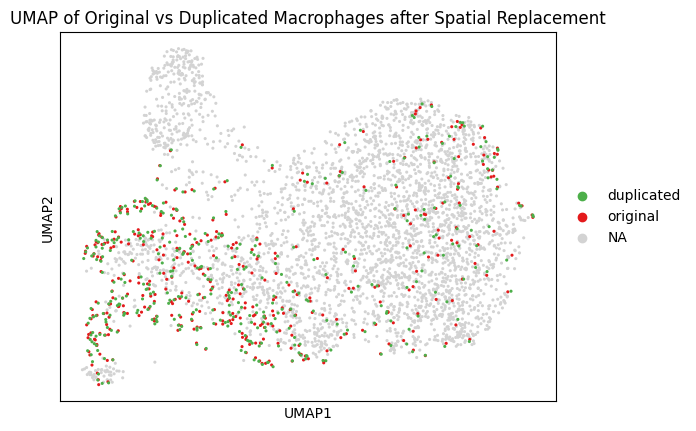

In [75]:
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title=f"UMAP of Original vs Duplicated {target_cell_type} after Spatial Replacement",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

In [76]:
# adata_displaced.write_h5ad("/home/nathanl/Data/adata_astrocyte_replaced.h5ad")
adata_displaced.write_h5ad(f"/home/nathanl/Data/VisiumHD_CRC/adata_{target_cell_type}_replaced.h5ad")

# results after training the models on the replaced adata object

In [ ]:
target_cell_type = "Macrophages"
target_region = "Tumor"  # Changed from list to string
source_regions = ["Stroma (Myofibroblast/SM/Endothelial)"]  # Changed to list for consistency

# for the data
LABEL: str = "cell_type_coarse"
COORDS: str = "spatial"
BATCH: str = "sample"
SAMPLE: str = "sample"
CELL_TYPE: str = "cell_type_coarse"
NICHE: str = "region_label"


# output of `python runner.py crc_visium_hd/duplicate` (scANVI and scVIVA latents)
adata_displaced = ad.read_h5ad(
    f"/home/nathanl/scviva_paper/crc_visium_hd/checkpoints/adata_{target_cell_type}_replaced/adata_{target_cell_type}_replaced_nicheVI.h5ad"
)
adata_displaced_target_type = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
print(adata_displaced_target_type)

AnnData object with n_obs × n_vars = 4115 × 4000
    obs: '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'centroid_x', 'centroid_y', 'index', 'n_counts', 
'niche_cluster', '_indices', 'resolvi_leiden_256_epochs150', 'cell_type_coarse', 'cell_type', 'sample', 
'region_label', 'replacement_status', '_scvi_sample', 'ln_s10_w400_scanvi_lr0.0005_poisson_compo_error', 
'ln_s10_w400_scanvi_lr0.0005_poisson_niche_error'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_banksy_02_harmony', 'X_resolvi', 'X_resolvi_128', 'X_resolvi_256', 'X_resolvi_256_epochs150', 
'X_scanvi', 'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.6',
'distance_neighbor', 'index_neighbor', 'ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI', 'neighborhood_composition',
'niche_distances', 'niche_indexes', 'qz1_m', 'qz1_m_niche_ct', 'simvi25_all_mae_50', 'simvi25_both_mae_50', 
'simvi25_interact_mae_50', 'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

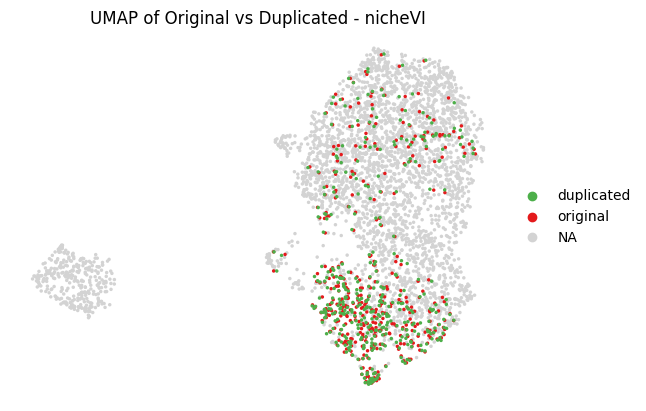

In [6]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated - nicheVI",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=25,
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURE_DIR}macrophage_umap_nicheVI.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURE_DIR}macrophage_umap_nicheVI.svg", bbox_inches="tight", dpi=300)

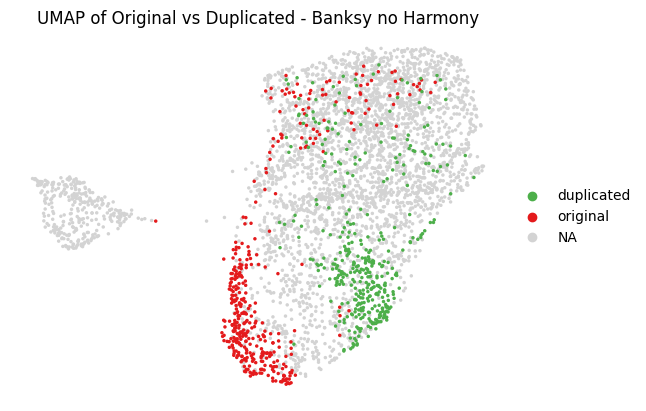

In [7]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="banksy_pc_20_lambda_0.2")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated - Banksy no Harmony",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=25,
    frameon=False,
    show=False,
)

plt.savefig(f"{FIGURE_DIR}macrophage_umap_banksy_noharmony.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURE_DIR}macrophage_umap_banksy_noharmony.svg", bbox_inches="tight", dpi=300)

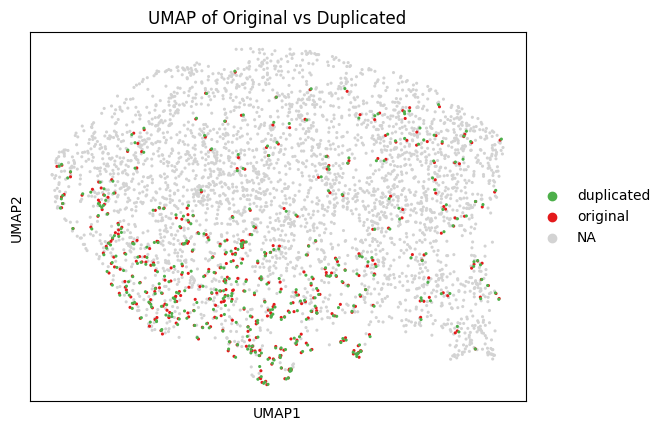

In [6]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_intrinsic_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

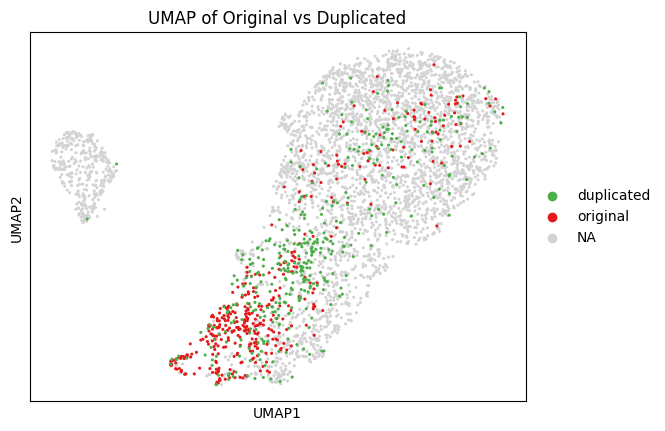

In [7]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_interact_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

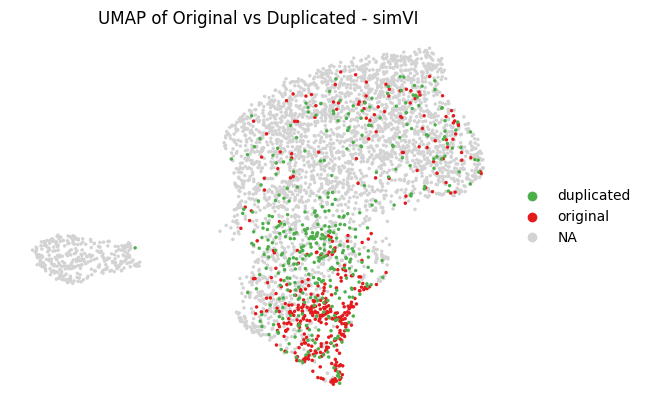

In [8]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_all_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated - simVI",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=25,
    frameon=False,
    show=False,
)

plt.savefig(f"{FIGURE_DIR}macrophage_umap_simVI.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURE_DIR}macrophage_umap_simVI.svg", bbox_inches="tight", dpi=300)

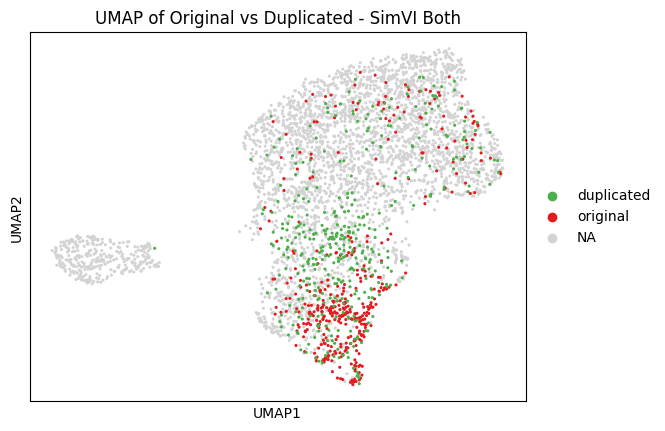

In [9]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_both_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated - SimVI Both",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

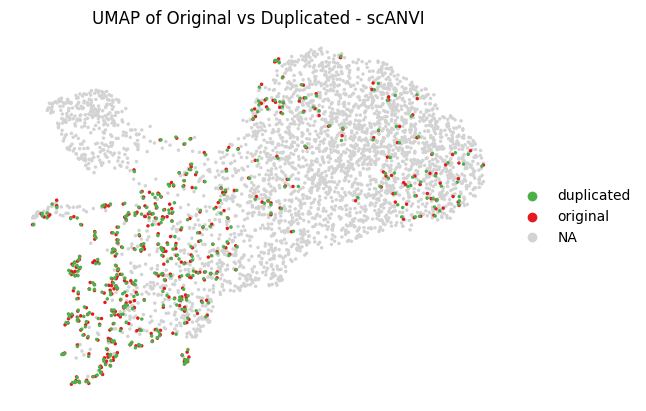

In [9]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="X_scanvi")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated - scANVI",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=25,
    frameon=False,
    show=False,
)

plt.savefig(f"{FIGURE_DIR}macrophage_umap_scanVI.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURE_DIR}macrophage_umap_scanVI.svg", bbox_inches="tight", dpi=300)

In [11]:
adata_displaced_target_type.obs["replacement_status"].value_counts()

replacement_status
untouched     3994
duplicated    1983
original      1983
Name: count, dtype: int64

In [11]:
from nichevi.spatial_analysis import _integration_lisi, _lisi_per_cell_type

adata_untouched_duplicated = adata_displaced_target_type[
    adata_displaced_target_type.obs["replacement_status"].isin(["untouched", "duplicated"])
].copy()
# sc.pp.pca(adata_untouched_duplicated, svd_solver="arpack")
for embedding in [
    # "X_pca",
    "X_scanvi",
    "banksy_pc_20_lambda_0.2",
    "ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI",
    "simvi25_intrinsic_mae_50",
    "simvi25_interact_mae_50",
    "simvi25_both_mae_50",
]:
    adata_untouched_duplicated.obs["iLISI_" + embedding] = _integration_lisi(
        adata_untouched_duplicated,
        embedding_key=embedding,
        label_key="replacement_status",
        n_neighbors=90,
        perplexity=30,
    )

Computing iLISI for X_scanvi based on replacement_status
Number of batches: 2
Min 0.9999993 Max 1.9999456
Median iLISI: 0.060659885
Mean iLISI: 0.19345172
Computing iLISI for banksy_pc_20_lambda_0.2 based on replacement_status
Number of batches: 2
Min 0.99999905 Max 2.0000002
Median iLISI: 0.026399612
Mean iLISI: 0.12961128
Computing iLISI for ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI based on replacement_status
Number of batches: 2
Min 0.99999905 Max 2.0000002
Median iLISI: 0.06576121
Mean iLISI: 0.1973031
Computing iLISI for simvi25_intrinsic_mae_50 based on replacement_status
Number of batches: 2
Min 0.99999905 Max 1.9999957
Median iLISI: 0.08000791
Mean iLISI: 0.20700029
Computing iLISI for simvi25_interact_mae_50 based on replacement_status
Number of batches: 2
Min 0.9999993 Max 1.9999969
Median iLISI: 0.057828903
Mean iLISI: 0.17670256
Computing iLISI for simvi25_both_mae_50 based on replacement_status
Number of batches: 2
Min 0.9999993 Max 1.9999995
Median iLISI: 0.052604556

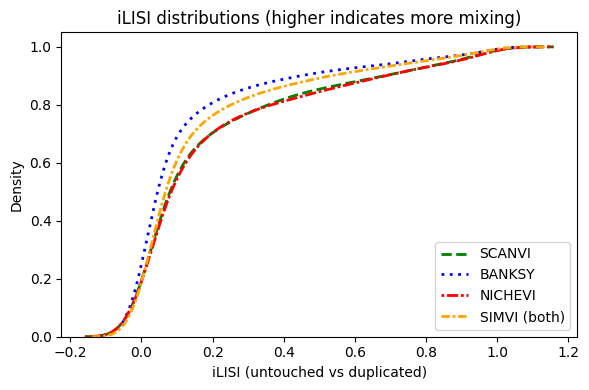

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define styling per method
styles = {
    "SCANVI": {"color": "green", "linestyle": "--"},
    "BANKSY": {"color": "blue", "linestyle": (0, (1, 2))},
    "NICHEVI": {"color": "red", "linestyle": (0, (1, 1, 4, 1))},
    "SIMVI (both)": {"color": "orange", "linestyle": (0, (3, 1, 1, 1))},
    "SIMVI (interact)": {"color": "brown", "linestyle": (0, (3, 5, 1, 5))},
    "SIMVI (intrinsic)": {"color": "pink", "linestyle": (0, (5, 5))},
    "PCA": {"color": "gray", "linestyle": "solid"},
}

# Map from plot label → obs key in adata
method_to_obsm = {
    "SCANVI": "iLISI_X_scanvi",
    "BANKSY": "iLISI_banksy_pc_20_lambda_0.2",
    "NICHEVI": "iLISI_ln_s10_w400_scanvi_lr0.0005_poisson_X_nicheVI",
    # "SIMVI (interact)": "iLISI_simvi25_interact_mae_50",
    # "SIMVI (intrinsic)": "iLISI_simvi25_intrinsic_mae_50",
    "SIMVI (both)": "iLISI_simvi25_both_mae_50",
    # "PCA": "iLISI_X_pca",
}

plt.figure(figsize=(6, 4))

for method, key in method_to_obsm.items():
    values = adata_untouched_duplicated.obs[key].dropna()
    sns.kdeplot(
        values,
        label=method,
        color=styles[method]["color"],
        linestyle=styles[method]["linestyle"],
        linewidth=2,
        common_norm=True,
        cumulative=True,  # or True if you want CDF
        # cumulative=False,  # or True if you want CDF
    )

plt.xlabel("iLISI (untouched vs duplicated)")
plt.ylabel("Density")
plt.title("iLISI distributions (higher indicates more mixing)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}macrophage_ilisi_comparison.png", dpi=300)
plt.savefig(f"{FIGURE_DIR}macrophage_ilisi_comparison.svg", dpi=300)

plt.show()